# Model analysis

Everything here reads from `models/*/*.json`, which every trainer writes. Retrain a
model and re-run the notebook — no numbers are hard-coded.

The question each section answers:

1. Did the GA actually learn, or did it plateau into noise?
2. How many games does it take to *tell* two agents apart?
3. What does the trained 2048 agent's score distribution look like?
4. Did the DQN learn Snake?
5. Who wins head to head, and is the gap real?

In [1]:
import json, statistics, sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "core").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from core.arena import compare, wilson_interval
from core.registry import list_agents, load_agent, make_game
from core.runner import play_episode
from vizstyle import INK_FAINT, INK_SOFT, colour_for, finish, new_figure, use_style

use_style()

def model(game, name):
    return json.loads((ROOT / "models" / game / f"{name}.json").read_text())

print("2048 :", list_agents("2048"))
print("snake:", list_agents("snake"))

2048 : ['random', 'first', 'ga', 'ga-flat']
snake: ['random', 'first', 'dqn', 'ga']


## 1. Did the GA learn?

Two runs of the same algorithm on 2048. `ga-flat` scored every individual on a fixed
12 games per generation. `ga` ramps from 12 up to 60, spending compute on precision
only once the population has converged and the differences have got small.

The holdout curve is the honest one: a fixed set of games, never used for selection,
so generations are comparable to each other.

findfont: Failed to find font weight 600, now using 700.


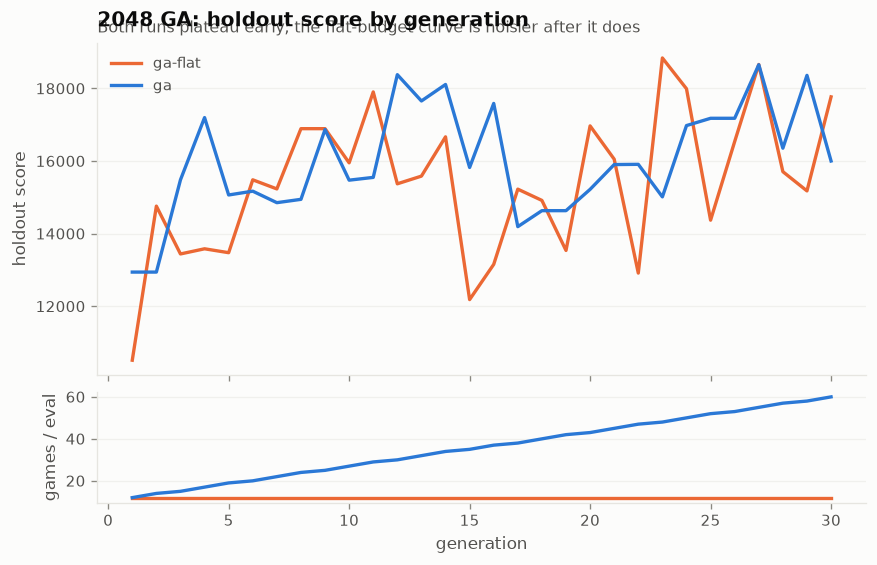

,ga-flat,ga
first-gen holdout,10515.0,12942.0
best holdout,18840.0,18654.0
final holdout,17769.0,16002.0
gen of best,23.0,27.0


In [2]:
runs = {name: model("2048", name)["history"] for name in ["ga-flat", "ga"]}

fig, (ax, ax2) = plt.subplots(
    2, 1, figsize=(7.2, 4.6), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

for name, history in runs.items():
    gens = [h["generation"] for h in history]
    ax.plot(gens, [h["holdout"] for h in history], color=colour_for(name), label=name)

finish(
    ax,
    title="2048 GA: holdout score by generation",
    subtitle="Both runs plateau early; the flat-budget curve is noisier after it does",
    ylabel="holdout score",
)

for name, history in runs.items():
    ax2.plot(
        [h["generation"] for h in history],
        [h["games_per_eval"] if "games_per_eval" in h else 12 for h in history],
        color=colour_for(name),
    )
finish(ax2, ylabel="games / eval", xlabel="generation", legend=False)
plt.show()

pd.DataFrame({
    name: {
        "first-gen holdout": history[0]["holdout"],
        "best holdout": max(h["holdout"] for h in history),
        "final holdout": history[-1]["holdout"],
        "gen of best": max(history, key=lambda h: h["holdout"])["generation"],
    }
    for name, history in runs.items()
}).round(0)

## 2. How much noise is in a fitness estimate?

This is the number that governs everything else. A single 2048 game is enormously
variable, so a fitness computed from a handful of games is mostly luck. Below,
the standard error of a mean-of-*n*-games fitness, as a fraction of the mean.

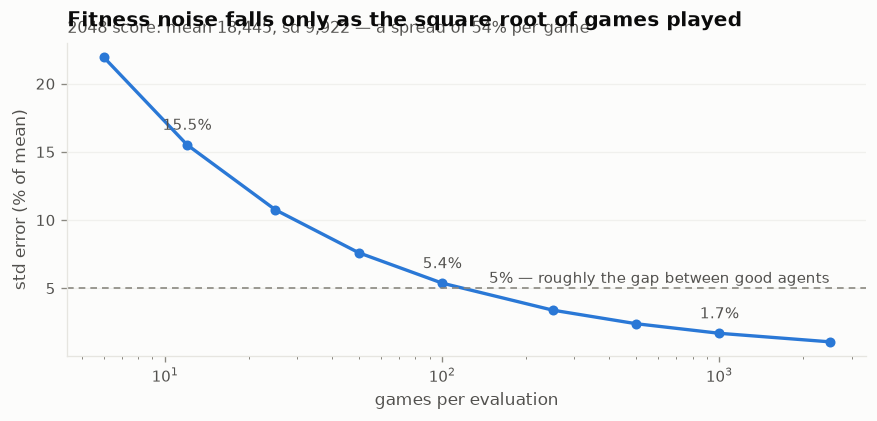

,std error,as % of mean
games per eval,,
6,4051.0,22.0
12,2864.0,15.5
25,1984.0,10.8
50,1403.0,7.6
100,992.0,5.4
250,628.0,3.4
500,444.0,2.4
1000,314.0,1.7
2500,198.0,1.1


In [3]:
game2048 = make_game("2048")
agent2048 = load_agent("2048", "ga")

episodes = [play_episode(game2048, [agent2048], 2_000_000 + i) for i in range(250)]
scores = np.array([e.scores[0] for e in episodes])
mean, sd = scores.mean(), scores.std(ddof=1)

budgets = np.array([6, 12, 25, 50, 100, 250, 500, 1000, 2500])
rel_err = sd / np.sqrt(budgets) / mean

fig, ax = new_figure(height=3.4)
ax.plot(budgets, rel_err * 100, color=colour_for("ga"), marker="o")
ax.set_xscale("log")
ax.axhline(5, color=INK_FAINT, linewidth=1, linestyle=(0, (4, 3)))
ax.text(budgets[-1], 5.4, "5% — roughly the gap between good agents",
        ha="right", fontsize=9, color=INK_SOFT)
for n in (12, 100, 1000):
    i = list(budgets).index(n)
    ax.annotate(f"{rel_err[i]*100:.1f}%", (n, rel_err[i] * 100),
                textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=9, color=INK_SOFT)
finish(ax,
       title="Fitness noise falls only as the square root of games played",
       subtitle=f"2048 score: mean {mean:,.0f}, sd {sd:,.0f} — a spread of {sd/mean:.0%} per game",
       xlabel="games per evaluation", ylabel="std error (% of mean)")
plt.show()

pd.DataFrame({"games per eval": budgets,
              "std error": (sd / np.sqrt(budgets)).round(0),
              "as % of mean": (rel_err * 100).round(1)}).set_index("games per eval")

## 3. What does the trained agent actually do?

Mean score alone hides the shape. The distribution shows whether an agent is
reliably decent or occasionally lucky.

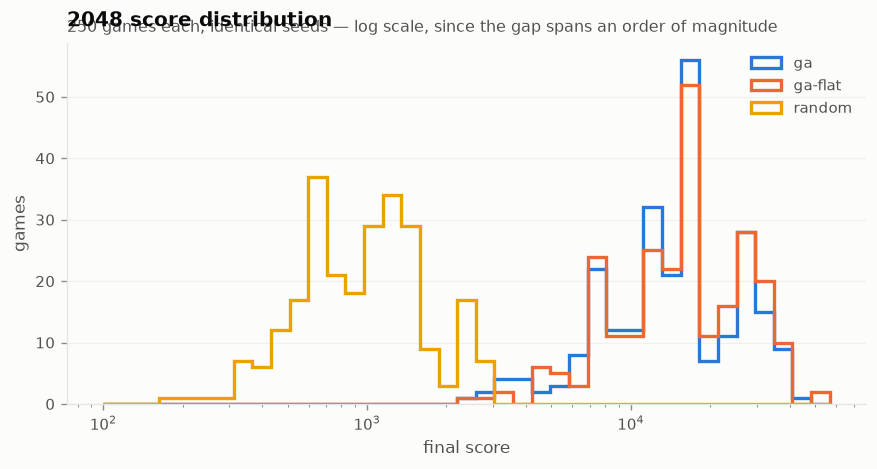

,mean,median,best,mean moves
ga,16568.0,15576.0,41536.0,942.0
ga-flat,17769.0,16240.0,51608.0,999.0
random,1090.0,990.0,2888.0,118.0


In [4]:
SAMPLE = 250
runs2048 = {}
for name in ["ga", "ga-flat", "random"]:
    agent = load_agent("2048", name)
    runs2048[name] = [
        play_episode(game2048, [agent], 4_000_000 + i) for i in range(SAMPLE)
    ]

fig, ax = new_figure()
bins = np.logspace(2, np.log10(max(e.scores[0] for r in runs2048.values() for e in r) * 1.1), 40)
for name, eps in runs2048.items():
    ax.hist([e.scores[0] for e in eps], bins=bins, histtype="step",
            linewidth=2, color=colour_for(name), label=name)
ax.set_xscale("log")
finish(ax, title="2048 score distribution",
       subtitle=f"{SAMPLE} games each, identical seeds — log scale, since the gap spans an order of magnitude",
       xlabel="final score", ylabel="games")
plt.show()

pd.DataFrame({
    name: {
        "mean": statistics.fmean(e.scores[0] for e in eps),
        "median": statistics.median(e.scores[0] for e in eps),
        "best": max(e.scores[0] for e in eps),
        "mean moves": statistics.fmean(e.steps for e in eps),
    }
    for name, eps in runs2048.items()
}).T.round(0)

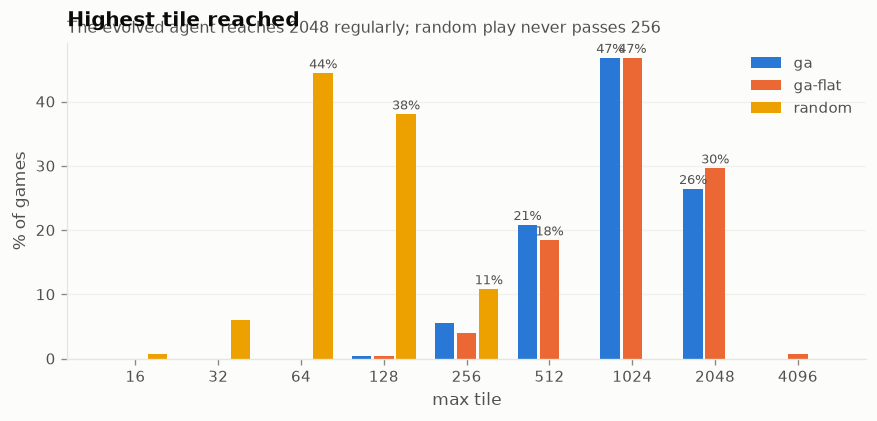

In [5]:
tiles = sorted({e.final["max_tile"] for eps in runs2048.values() for e in eps})
names = list(runs2048)
width = 0.8 / len(names)

fig, ax = new_figure(height=3.4)
for k, name in enumerate(names):
    counts = [
        sum(1 for e in runs2048[name] if e.final["max_tile"] == t) / SAMPLE * 100
        for t in tiles
    ]
    offset = (k - (len(names) - 1) / 2) * width
    bars = ax.bar([i + offset for i in range(len(tiles))], counts,
                  width * 0.88, color=colour_for(name), label=name)
    for rect, value in zip(bars, counts):
        if value >= 8:  # label only the bars worth reading
            ax.annotate(f"{value:.0f}%", (rect.get_x() + rect.get_width() / 2, value),
                        textcoords="offset points", xytext=(0, 3),
                        ha="center", fontsize=8, color=INK_SOFT)
ax.set_xticks(range(len(tiles)), [str(t) for t in tiles])
finish(ax, title="Highest tile reached",
       subtitle="The evolved agent reaches 2048 regularly; random play never passes 256",
       xlabel="max tile", ylabel="% of games")
plt.show()

## 4. Did the DQN learn Snake?

A different family of model on a different game: instead of tuning weights on
features a human chose, the network learns its own value estimate from raw
observations. The curve below is greedy evaluation on fixed seeds, measured
periodically during training.

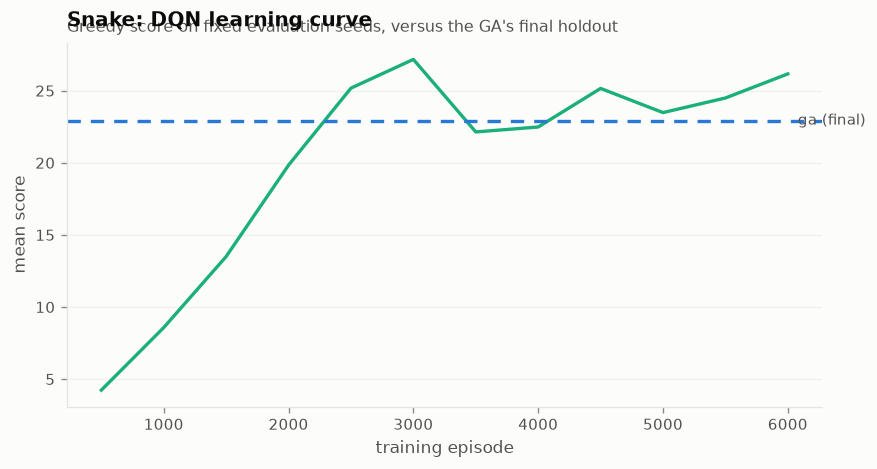

,episode,epsilon,loss,eval_score
4,2500,0.208,0.589,25.185
5,3000,0.050,0.798,27.176
6,3500,0.050,1.414,22.147
7,4000,0.050,1.422,22.489
8,4500,0.050,2.020,25.163
9,5000,0.050,2.047,23.488
10,5500,0.050,2.302,24.501
11,6000,0.050,2.172,26.171


In [6]:
dqn_history = model("snake", "dqn")["history"]
ga_snake = model("snake", "ga")

fig, ax = new_figure()
ax.plot([h["episode"] for h in dqn_history], [h["eval_score"] for h in dqn_history],
        color=colour_for("dqn"), label="dqn")
ax.axhline(ga_snake["holdout_score"], color=colour_for("ga"),
           linewidth=2, linestyle=(0, (4, 3)))
ax.text(dqn_history[-1]["episode"], ga_snake["holdout_score"],
        "  ga (final)", va="center", fontsize=9, color=INK_SOFT)
finish(ax, title="Snake: DQN learning curve",
       subtitle="Greedy score on fixed evaluation seeds, versus the GA's final holdout",
       xlabel="training episode", ylabel="mean score", legend=False)
plt.show()

pd.DataFrame(dqn_history)[["episode", "epsilon", "loss", "eval_score"]].round(3).tail(8)

## 5. Head to head

The comparison that matters, and the one easiest to get wrong. Three agents share a
board, seats rotate every game so no one benefits from a starting position, and every
matchup uses the same seeds.

**Read the error bars, not the bars.** Overlapping intervals mean the ranking is not
established, however different the percentages look.

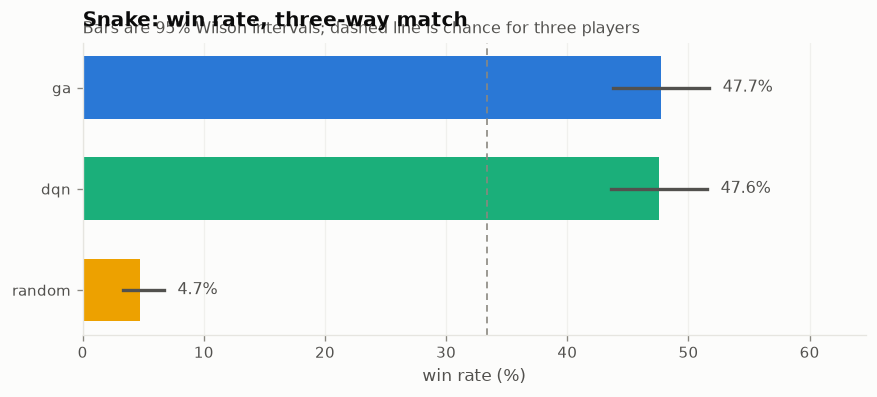

,games,wins,win rate,95% CI,mean score
ga,600,286.3,47.7%,43.8% – 51.7%,40.42
dqn,600,285.3,47.6%,43.6% – 51.6%,41.75
random,600,28.3,4.7%,3.3% – 6.7%,2.41


In [7]:
CONTENDERS = ["ga", "dqn", "random"]
results = compare("snake", CONTENDERS, games=600,
                  game_kwargs={"num_players": len(CONTENDERS)}, quiet=True)

rates = {n: results[n].win_rate for n in CONTENDERS}
order = sorted(CONTENDERS, key=lambda n: rates[n][0])

fig, ax = new_figure(height=3.2)
for i, name in enumerate(order):
    rate, low, high = rates[name]
    ax.barh(i, rate * 100, height=0.62, color=colour_for(name))
    ax.plot([low * 100, high * 100], [i, i], color=INK_SOFT, linewidth=2)
    ax.annotate(f"{rate:.1%}", (high * 100, i), textcoords="offset points",
                xytext=(8, 0), va="center", fontsize=9.5, color=INK_SOFT)
ax.set_yticks(range(len(order)), order)
ax.axvline(100 / len(CONTENDERS), color=INK_FAINT, linewidth=1, linestyle=(0, (4, 3)))
ax.set_xlim(0, max(h for _, _, h in rates.values()) * 100 * 1.25)
finish(ax, title="Snake: win rate, three-way match",
       subtitle="Bars are 95% Wilson intervals; dashed line is chance for three players",
       xlabel="win rate (%)", legend=False)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
plt.show()

pd.DataFrame({
    n: {
        "games": results[n].games,
        "wins": round(results[n].wins, 1),
        "win rate": f"{rates[n][0]:.1%}",
        "95% CI": f"{rates[n][1]:.1%} – {rates[n][2]:.1%}",
        "mean score": round(results[n].mean_score, 2),
    }
    for n in order[::-1]
}).T

In [8]:
# Pairwise, so a weak third player cannot flatter either contender.
pair = compare("snake", ["ga", "dqn"], games=600,
               game_kwargs={"num_players": 2}, quiet=True)

rows = []
for name, record in pair.items():
    rate, low, high = record.win_rate
    rows.append({"agent": name, "win rate": f"{rate:.1%}",
                 "95% CI": f"{low:.1%} – {high:.1%}",
                 "mean score": round(record.mean_score, 2)})

decisive = not (pair["ga"].win_rate[1] < 0.5 < pair["ga"].win_rate[2])
print("ga vs dqn, 600 games, seats rotated")
print("verdict:", "a real difference" if decisive else "NOT separable at this sample size")
pd.DataFrame(rows).set_index("agent")

ga vs dqn, 600 games, seats rotated
verdict: NOT separable at this sample size


,win rate,95% CI,mean score
agent,,,
ga,47.2%,43.2% – 51.2%,39.41
dqn,52.8%,48.8% – 56.8%,40.56


## Takeaways

- **Measure the noise before trusting a ranking.** Section 2 is the reason the GA
  plateaus: once candidates are within a few percent of each other, a 12-game
  fitness cannot tell them apart, and selection starts sorting on luck.
- **Error bars decide, not bar heights.** Section 5 reports Wilson intervals for
  exactly this reason.
- **Common random numbers are free accuracy.** Every comparison here replays the
  same seeds for every agent, which cancels shared luck.

To add a game, implement `core.game.Game` and register it in `core/registry.py`;
both trainers and every chart above work on it unchanged.